In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Reading Data ##

In [2]:
data = pd.read_csv('sensor_signals_low_noise.csv')

t = data['timestamp'].values
s1 = data['sensor_0'].values
s2 = data['sensor_1'].values
s3 = data['sensor_2'].values
# checking loading of data
print(len(t), len(s1), len(s2), len(s3))
print(data.head())

12000 12000 12000 12000
   timestamp  sensor_0  sensor_1  sensor_2
0      0.000  0.126234  0.226082  0.054877
1      0.005  0.307867  0.352809  0.348131
2      0.010 -0.078792 -0.317854 -0.077885
3      0.015 -0.468390 -0.497180 -0.579247
4      0.020  0.215240  0.215435  0.243391


## Plotting the signals ##

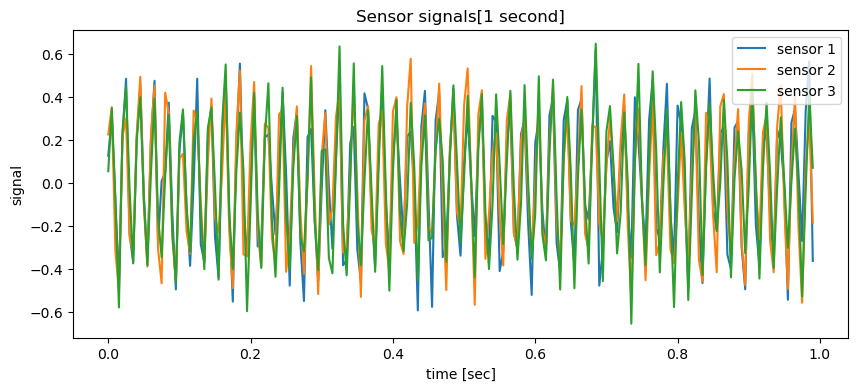

In [3]:
plt.figure(figsize=(10,4))

plt.plot(t[0:199], s1[0:199], label="sensor 1")
plt.plot(t[0:199], s2[0:199], label="sensor 2")
plt.plot(t[0:199], s3[0:199], label="sensor 3")

plt.xlabel("time [sec]")
plt.ylabel("signal")
plt.legend()
plt.title("Sensor signals[1 second]")
plt.show()

## Problem Parameters ##

In [4]:
f0 = 50 # Hz
c = 343 # speed of sound in m/s
sensor_x = np.array([3, 5, 7]) # sensor locations in meters
sensor_y = 8

stage_y = 0

T = 1 #window length in seconds
dx = 0.01 # step in x axis for plotting
x_candidates = np.arange(0, 10, dx) # candidate locations for the source

## Defining function for calculating distance and phase ##

In [5]:
def compute_phase (x_candidate, sensor_x):

    distance = np.sqrt((x_candidate - sensor_x)**2 + sensor_y**2)
    tau = distance / c
    phi = 2*np.pi*f0*tau
    return phi

## Defining function for building feature matrix ##

In [6]:
def build_feature_matrix(t_window, x_candidate):
    feature_list = []
    for k in range(3):
        phi_k = compute_phase(x_candidate, sensor_x[k])
        feature_k = np.cos(2*np.pi*f0*t_window - phi_k)
        feature_list.append(feature_k)
    N = len(t_window)
    X = np.zeros((3*N,3))

    X[:N,0] = feature_list[0]
    X[N:2*N,1] = feature_list[1]
    X[2*N:3*N,2] = feature_list[2]
    
    return X   

## Setting the time data into time windows

In [7]:
def set_time_windows(t, T):
  windows =[]
  t_start = t[0]
  
  while t_start < t[-1]:
      idx = np.where((t >= t_start) & (t < t_start + T))[0]
      if len(idx) > 0:
          windows.append(idx)
  
      t_start += T
  print(f"number of windows: {len(windows)}")
  return windows

## Main Algorithm

In [8]:
def main(t,s1,s2,s3,windows):
    estimated_positions = []

    for idx in windows:
    
        t_window = t[idx]
        
        s_window = np.concatenate([s1[idx], s2[idx], s3[idx]])
        mmse_values = []
        for x_c in x_candidates:
            X = build_feature_matrix(t_window, x_c)
            w = np.linalg.pinv(X) @ s_window
            error = np.linalg.norm(X @ w - s_window)**2
            mmse_values.append(error)
        best_x = x_candidates[np.argmin(mmse_values)]
        estimated_positions.append(best_x)
    min_idx = np.argmin(mmse_values)
    min_x = x_candidates[min_idx]
    min_mmse = mmse_values[min_idx]
    plt.plot(x_candidates, mmse_values)
    plt.scatter(min_x, min_mmse, color='red', label=f"min MMSE at x={min_x:.2f} m")
    plt.legend()

    plt.xlabel("candidate position")
    plt.ylabel("MMSE")
    plt.title("MMSE vs candidate position")
    
    plt.show()
    time_windows = np.arange(len(estimated_positions))* T

    plt.figure(figsize=(10,4))
    
    plt.plot(time_windows, estimated_positions, label="estimated position")
    
    plt.xlabel("time [sec]")
    plt.ylabel("estimated_positions")
    
    plt.title("Estimated speaker position")
    
    plt.show()
    return estimated_positions

## Using for low noise case

number of windows: 60


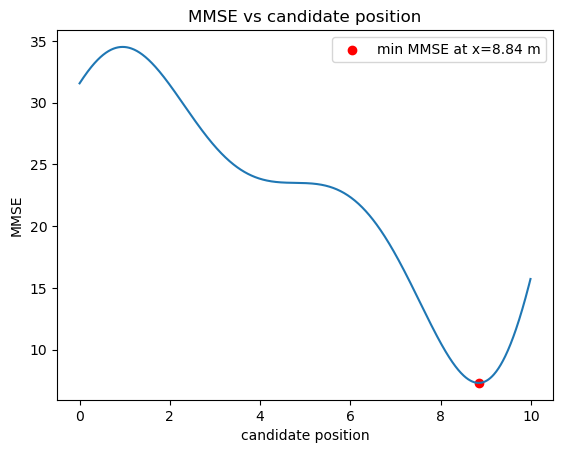

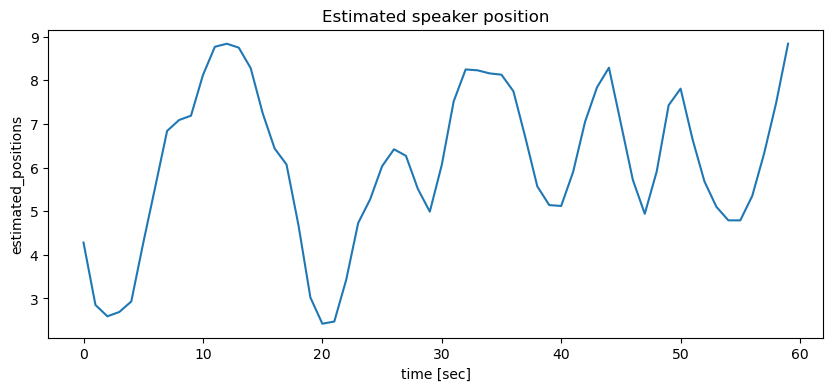

In [9]:
windows_1 = set_time_windows(t, 1)
positions_low =main(t,s1,s2,s3,windows_1)

## Case medium noise

12000 12000 12000 12000
   timestamp  sensor_0  sensor_1  sensor_2
0      0.000  0.100153  0.629215 -0.385880
1      0.005  1.038118  0.915508  0.832133
2      0.010 -1.593990  0.684174 -0.268444
3      0.015 -0.061675 -1.005900 -0.319866
4      0.020 -1.289789  0.065431 -0.810720


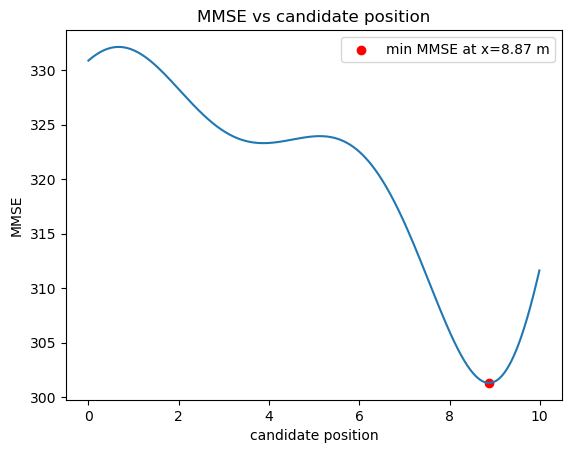

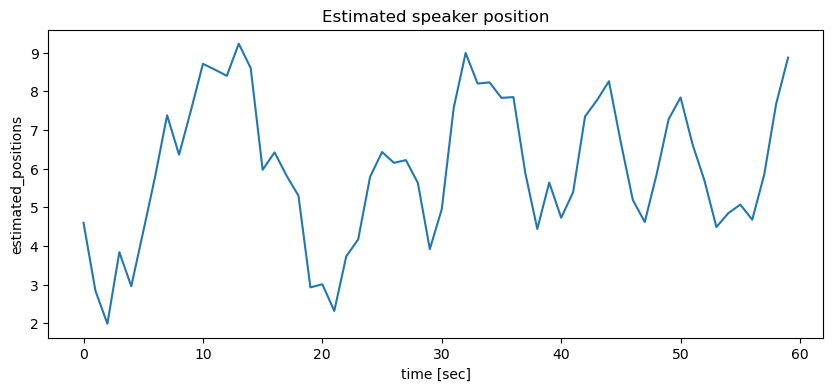

In [10]:
data_medium = pd.read_csv('sensor_signals_medium_noise.csv')

t_med = data_medium['timestamp'].values
s1_med = data_medium['sensor_0'].values
s2_med = data_medium['sensor_1'].values
s3_med = data_medium['sensor_2'].values
# checking loading of data
print(len(t_med), len(s1_med), len(s2_med), len(s3_med))
print(data_medium.head())
positions_med = main(t_med,s1_med,s2_med,s3_med,windows_1)


## Case high noise

12000 12000 12000 12000
   timestamp  sensor_0  sensor_1  sensor_2
0      0.000  0.876649  0.628187 -0.818419
1      0.005 -1.375107  2.163698  2.859382
2      0.010 -0.353495 -1.063635  0.174894
3      0.015  0.136623  1.067443 -0.974546
4      0.020 -2.245813 -0.208172  0.518796


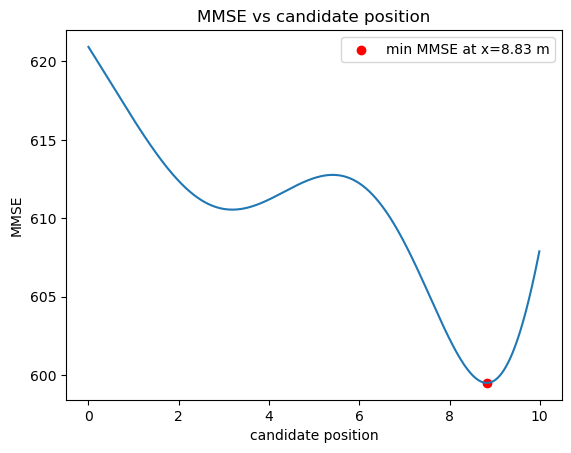

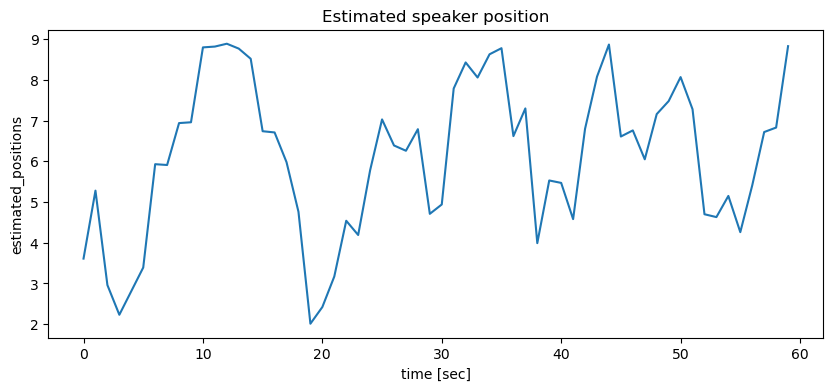

In [11]:
data_high = pd.read_csv('sensor_signals_high_noise.csv')

t_high = data_high['timestamp'].values
s1_high = data_high['sensor_0'].values
s2_high = data_high['sensor_1'].values
s3_high = data_high['sensor_2'].values
# checking loading of data
print(len(t_high), len(s1_high), len(s2_high), len(s3_high))
print(data_high.head())
positions_high = main(t_high,s1_high,s2_high,s3_high,windows_1)

## Checking the affect of different time windows

In [12]:
T_small = 0.2
windows_small = set_time_windows(t, T_small)
T_mid = 0.5
windows_mid = set_time_windows(t, T_mid)
T_large = 2
windows_large = set_time_windows(t, T_large)

number of windows: 300
number of windows: 120
number of windows: 30


## For windows size 0.2 [sec]

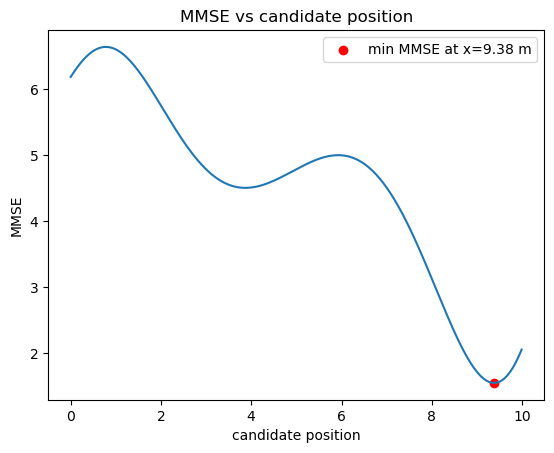

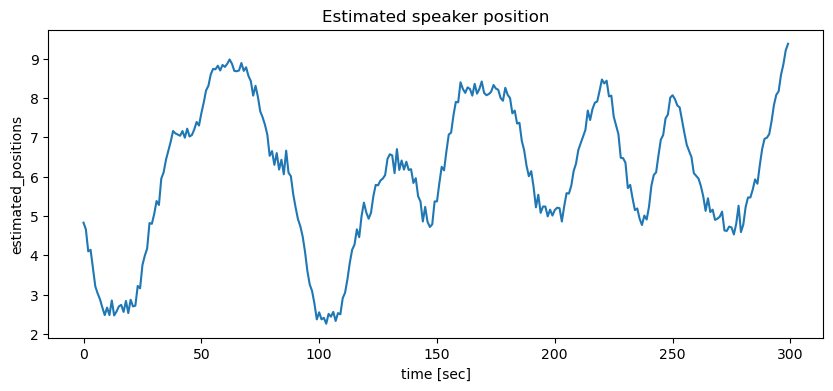

In [13]:
positions_T02 =main(t,s1,s2,s3,windows_small)

## For windows size 0.5 [sec]

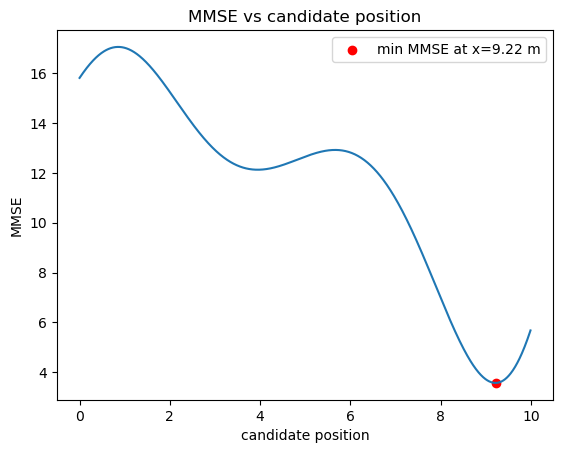

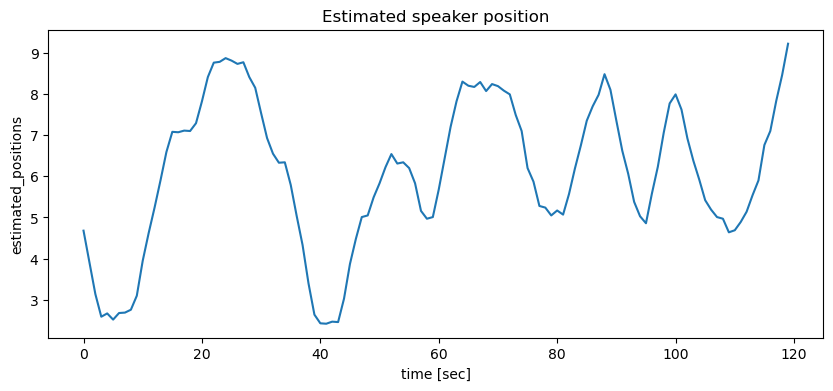

In [14]:
positions_T05 = main(t,s1,s2,s3,windows_mid)

## For windows size 2 [sec]

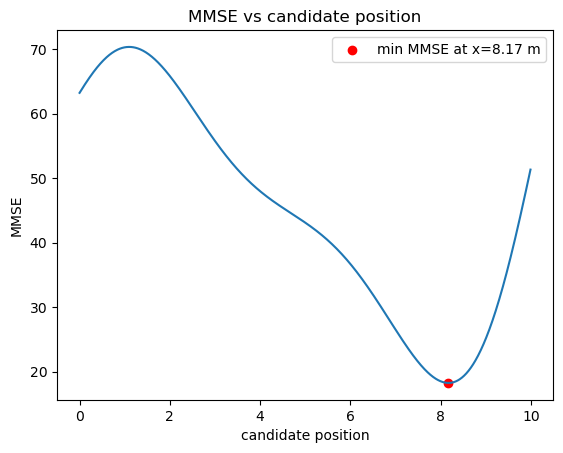

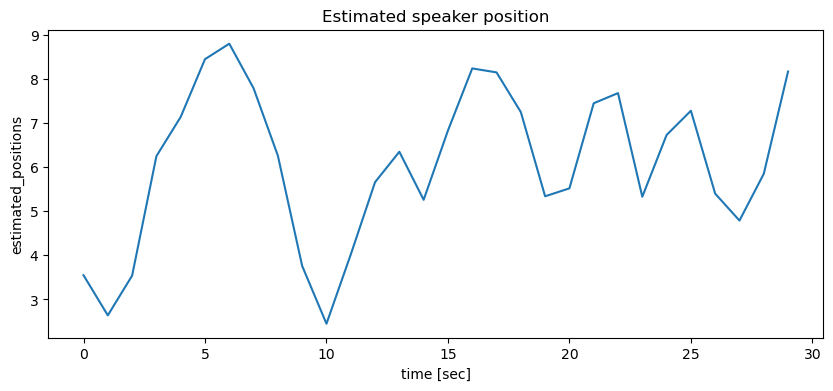

In [15]:
positions_T2 = main(t,s1,s2,s3,windows_large)

## comparing graphs

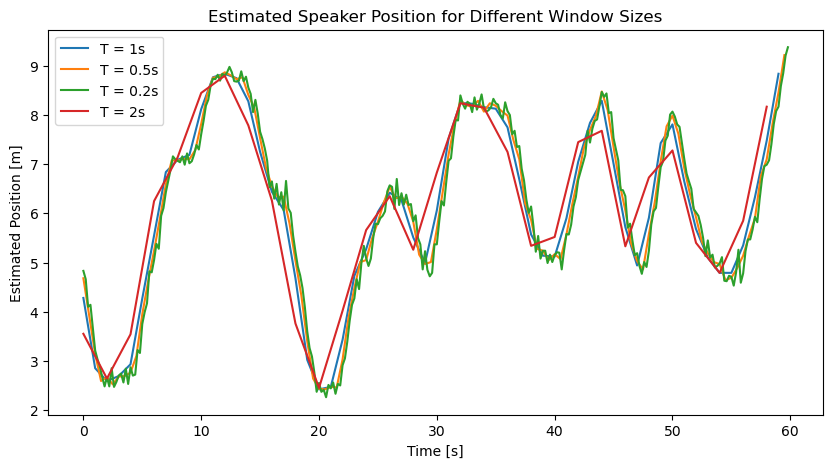

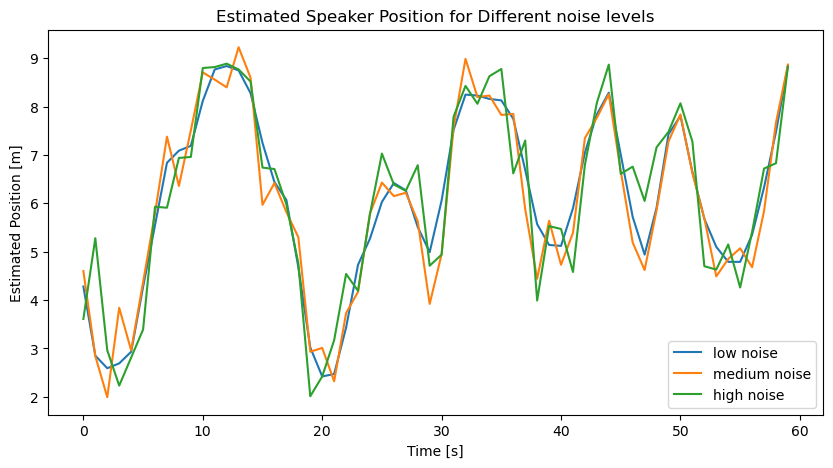

In [16]:
time_T1 = np.arange(len(positions_low)) * 1
time_T05 = np.arange(len(positions_T05)) * 0.5
time_T02 = np.arange(len(positions_T02)) * 0.2
time_T2 = np.arange(len(positions_T2)) * 2
plt.figure(figsize=(10,5))

plt.plot(time_T1, positions_low, label="T = 1s")
plt.plot(time_T05, positions_T05, label="T = 0.5s")
plt.plot(time_T02, positions_T02, label="T = 0.2s")
plt.plot(time_T2, positions_T2, label="T = 2s")

plt.xlabel("Time [s]")
plt.ylabel("Estimated Position [m]")
plt.title("Estimated Speaker Position for Different Window Sizes")

plt.legend()
plt.show()

plt.figure(figsize=(10,5))

plt.plot(time_T1, positions_low, label="low noise")
plt.plot(time_T1, positions_med, label="medium noise")
plt.plot(time_T1, positions_high, label="high noise")

plt.xlabel("Time [s]")
plt.ylabel("Estimated Position [m]")
plt.title("Estimated Speaker Position for Different noise levels")

plt.legend()
plt.show()